In [1]:
import scanpy as sc
import anndata
from scipy import io
from scipy.sparse import coo_matrix, csr_matrix
import numpy as np
import os
import pandas as pd

In [2]:
dir()

['In',
 'Out',
 '_',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_dh',
 '_i',
 '_i1',
 '_i2',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'anndata',
 'coo_matrix',
 'csr_matrix',
 'exit',
 'get_ipython',
 'io',
 'np',
 'os',
 'pd',
 'quit',
 'sc']

In [3]:
amp2 = sc.read("/rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/AMP2_data/AMPII_annotated.h5ad")
amp2

AnnData object with n_obs × n_vars = 322001 × 31897
    obs: 'library_id', 'ngenes', 'total_UMI', 'pct_mitochondrial', 'pct_ribosomal', 'scrub_doublet_scores', 'new_cluster_name_AMP2021', 'cell_type_AMP2021', 'cell_lineage', 'study_id', 'disease', 'cluster name'
    var: 'gene_ids', 'feature_types', 'highly_variable'
    uns: 'cluster name_colors'
    obsm: 'X_umap'
    layers: 'counts'

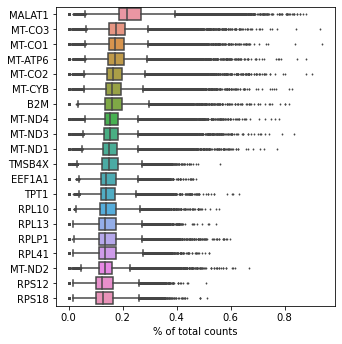

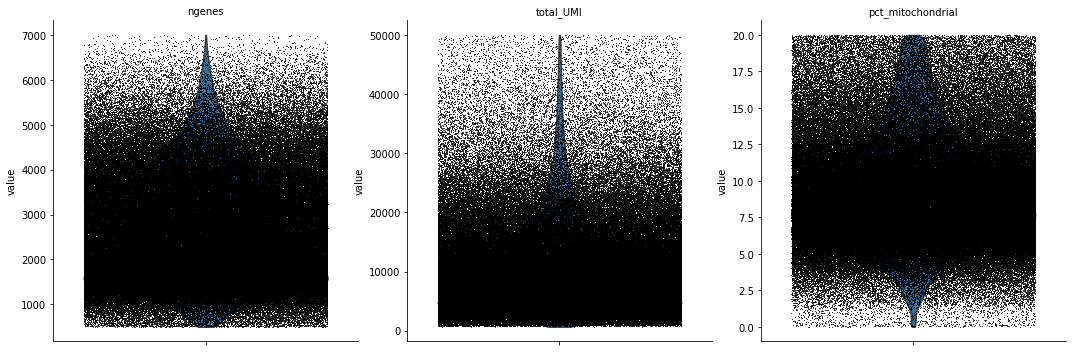

In [9]:
sc.pl.highest_expr_genes(amp2, n_top=20, )
sc.pl.violin(amp2, ['ngenes', 'total_UMI', 'pct_mitochondrial'],
             jitter=0.4, multi_panel=True)

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


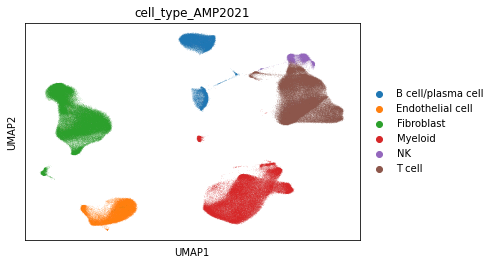

In [10]:
adata=amp2
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.pl.umap(adata, color=['cell_type_AMP2021'])

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


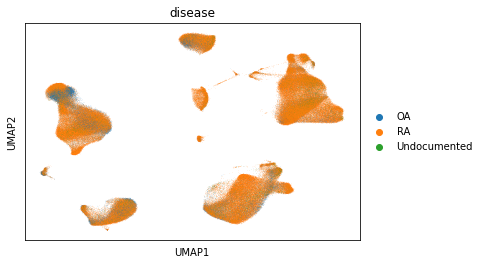

In [11]:
sc.pl.umap(adata, color=['disease'])

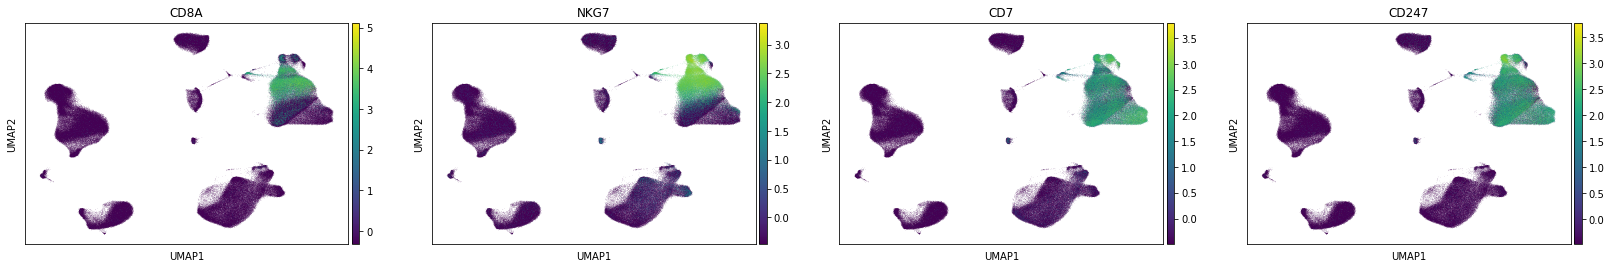

In [12]:
sc.pl.umap(adata, color=['CD8A', 'NKG7', 'CD7', 'CD247'])

In [14]:
sc.tl.rank_genes_groups(adata, 'cell_type_AMP2021', method='t-test')

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(


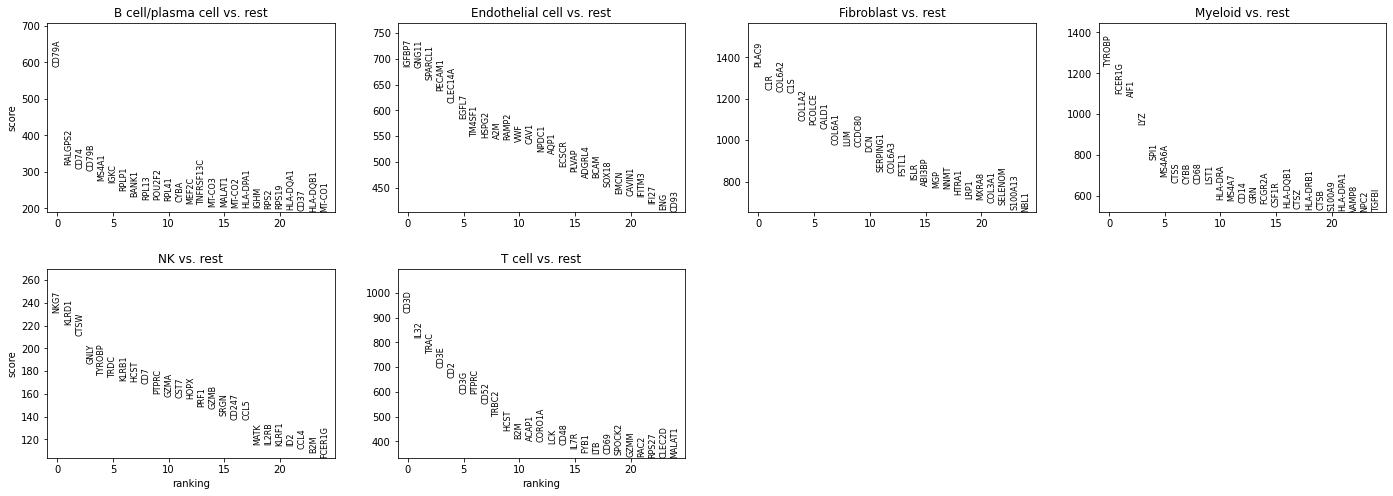

In [15]:
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [16]:
adata_fibro = adata[adata.obs['cell_type_AMP2021'].isin(['Fibroblast'])]
sc.pp.highly_variable_genes(adata_fibro, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata_fibro, max_value=10)
sc.tl.pca(adata_fibro, svd_solver='arpack')

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:784: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(var)


In [30]:
sc.pp.neighbors(adata_fibro, n_neighbors=10, n_pcs=40)

/rds/homes/m/mahonyc/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


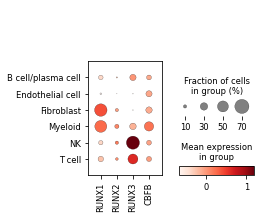

In [5]:
sc.pl.dotplot(adata, ['RUNX1', 'RUNX2', 'RUNX3', 'CBFB'], groupby='cell_type_AMP2021')

In [2]:
import dill
#dill.dump_session('/rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/AMP2_data/amp2_env.db')
dill.load_session('/rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/AMP2_data/amp2_env.db')